In [1]:
#!/usr/bin/env python
# =============================================================================
#  SIH 26052 — AI/ML ANC for Defence Communications
#  DCCRN (Deep Complex Convolution Recurrent Network) Training Notebook
#  Target: Kaggle T4 GPU | MAD + LibriSpeech datasets
# =============================================================================
# Copy each section (marked with ## CELL) into a separate Kaggle notebook cell.

In [2]:
!pip install -q pesq pystoi soundfile onnx onnxruntime

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 49.0 MB/s eta 0:00:00


In [3]:
# CELL 1: Install dependencies & imports
# =========================================================================
# !pip install -q pesq pystoi librosa soundfile onnx onnxruntime

import numpy as np
import librosa
import soundfile as sf
import os
import glob
import random
import math
import pandas as pd
from collections import defaultdict
from typing import Optional, Tuple, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from pesq import pesq
from pystoi import stoi
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
# CELL 2: Configuration
# =========================================================================
class Config:
    """All hyperparameters and paths in one place."""
    # --- Paths (Kaggle) ---
    DATASET_ROOT = "/kaggle/input"
    OUTPUT_DIR = "/kaggle/working"
    CHECKPOINT_DIR = "/kaggle/working/checkpoints"

    # --- Audio ---
    SR = 16000
    CLIP_SECONDS = 4          # 4 seconds per training clip
    CLIP_SAMPLES = SR * CLIP_SECONDS  # 64000

    # --- STFT ---
    N_FFT = 512
    WIN_LENGTH = 512          # 32ms window
    HOP_LENGTH = 128          # 8ms hop → allows < 20ms latency
    FREQ_BINS = N_FFT // 2 + 1  # 257

    # --- Model (DCCRN) ---
    ENCODER_CHANNELS = [16, 32, 64, 64, 128]  # 5 encoder layers
    KERNEL_SIZE = (5, 2)      # (freq, time) kernel
    STRIDE = (2, 1)           # downsample in frequency only
    LSTM_HIDDEN = 128
    LSTM_LAYERS = 2
    CAUSAL = True             # causal mode for real-time inference

    # --- Training ---
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    MAX_EPOCHS = 30
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 0.01
    PATIENCE = 8
    GRAD_CLIP = 5.0
    USE_AMP = True            # mixed precision training

    # --- Loss weights ---
    SI_SNR_WEIGHT = 0.7
    MRSTFT_WEIGHT = 0.3

    # --- Dataset ---
    NUM_TRAIN = 12000         # number of training pairs to generate
    NUM_VAL = 1500
    NUM_TEST_PER_SNR = 30
    SNR_RANGE = (-10, 15)     # uniform sampling during training
    SNR_TEST_LEVELS = [-10, -5, 0, 5, 10, 15]

    # MAD label mapping (from the MAD paper)
    MAD_LABELS = {
        0: "gunshot",
        1: "helicopter",
        2: "jet",
        3: "tank",
        4: "artillery",
        5: "explosion",
        6: "siren",
    }

cfg = Config()
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
print("Config loaded.")

Config loaded.


In [5]:
# CELL 3: Find and index dataset files
# =========================================================================
# --- Find MAD noise files ---
noise_files = sorted(glob.glob(
    os.path.join(cfg.DATASET_ROOT, "**", "MAD_dataset", "**", "*.wav"),
    recursive=True
))
print(f"Found {len(noise_files)} MAD noise files.")

# --- Find LibriSpeech speech files ---
speech_files = sorted(glob.glob(
    os.path.join(cfg.DATASET_ROOT, "**", "*.flac"),
    recursive=True
))
print(f"Found {len(speech_files)} LibriSpeech speech files.")

# --- Categorize noise files by label (folder structure) ---
# MAD structure: .../MAD_dataset/{label_id}/*.wav
noise_by_category = defaultdict(list)
for f in noise_files:
    # Extract the category from the parent folder name
    parent = os.path.basename(os.path.dirname(f))
    try:
        label_id = int(parent)
        category = cfg.MAD_LABELS.get(label_id, f"unknown_{parent}")
    except ValueError:
        category = parent
    noise_by_category[category].append(f)

print("\nNoise categories:")
for cat, files in sorted(noise_by_category.items()):
    print(f"  {cat}: {len(files)} files")

Found 7466 MAD noise files.
Found 137876 LibriSpeech speech files.

Noise categories:
  artillery: 6 files
  explosion: 5 files
  helicopter: 1 files
  jet: 4 files
  siren: 7 files
  tank: 9 files
  unknown_007: 6 files
  unknown_008: 1 files
  unknown_009: 9 files
  unknown_010: 2 files
  unknown_011: 4 files
  unknown_012: 7 files
  unknown_013: 5 files
  unknown_014: 5 files
  unknown_015: 9 files
  unknown_016: 6 files
  unknown_017: 5 files
  unknown_018: 15 files
  unknown_019: 2 files
  unknown_020: 23 files
  unknown_021: 2 files
  unknown_022: 3 files
  unknown_023: 2 files
  unknown_024: 3 files
  unknown_025: 18 files
  unknown_026: 2 files
  unknown_027: 9 files
  unknown_028: 6 files
  unknown_029: 10 files
  unknown_030: 3 files
  unknown_031: 7 files
  unknown_032: 6 files
  unknown_033: 1 files
  unknown_034: 1 files
  unknown_035: 5 files
  unknown_036: 4 files
  unknown_037: 13 files
  unknown_038: 10 files
  unknown_039: 8 files
  unknown_040: 17 files
  unknown_041

In [6]:
# CELL 4: Audio utility functions
# =========================================================================
def load_audio(path: str, sr: int = cfg.SR, duration: Optional[float] = None) -> np.ndarray:
    """Load audio file, resample to target SR, optionally trim to duration."""
    y, orig_sr = librosa.load(path, sr=sr, duration=duration)
    return y


def pad_or_crop(audio: np.ndarray, target_len: int, random_crop: bool = True) -> np.ndarray:
    """Pad (by looping) or crop audio to exactly target_len samples."""
    if len(audio) < target_len:
        # Loop the audio to fill
        reps = int(np.ceil(target_len / max(len(audio), 1)))
        audio = np.tile(audio, reps)
    if len(audio) > target_len:
        if random_crop:
            start = random.randint(0, len(audio) - target_len)
        else:
            start = 0
        audio = audio[start:start + target_len]
    return audio[:target_len]


def mix_at_snr(clean: np.ndarray, noise: np.ndarray, snr_db: float) -> Tuple[np.ndarray, np.ndarray]:
    """
    Mix clean speech with noise at a specific SNR level.
    Returns: (mixture, scaled_noise)
    """
    noise = pad_or_crop(noise, len(clean), random_crop=True)

    clean_power = np.mean(clean ** 2) + 1e-12
    noise_power = np.mean(noise ** 2) + 1e-12
    target_noise_power = clean_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    scaled_noise = noise * scale
    mixture = clean + scaled_noise

    # Prevent clipping
    peak = np.max(np.abs(mixture))
    if peak > 0.99:
        mixture = mixture * 0.99 / peak
        clean = clean * 0.99 / peak

    return mixture, clean


def compute_snr(clean: np.ndarray, enhanced: np.ndarray) -> float:
    """Compute output SNR in dB."""
    min_len = min(len(clean), len(enhanced))
    clean, enhanced = clean[:min_len], enhanced[:min_len]
    noise = clean - enhanced
    return 10 * np.log10(np.sum(clean ** 2) / (np.sum(noise ** 2) + 1e-12))


def compute_si_snr(reference: np.ndarray, estimate: np.ndarray) -> float:
    """Compute Scale-Invariant SNR."""
    min_len = min(len(reference), len(estimate))
    ref = reference[:min_len]
    est = estimate[:min_len]

    ref = ref - np.mean(ref)
    est = est - np.mean(est)

    dot = np.sum(ref * est)
    s_target = dot * ref / (np.sum(ref ** 2) + 1e-12)
    e_noise = est - s_target

    si_snr = 10 * np.log10(np.sum(s_target ** 2) / (np.sum(e_noise ** 2) + 1e-12))
    return si_snr


def compute_pesq_score(clean: np.ndarray, enhanced: np.ndarray, sr: int = cfg.SR) -> Optional[float]:
    """Compute PESQ (wideband)."""
    min_len = min(len(clean), len(enhanced))
    try:
        return pesq(sr, clean[:min_len], enhanced[:min_len], 'wb')
    except Exception:
        return None


def compute_stoi_score(clean: np.ndarray, enhanced: np.ndarray, sr: int = cfg.SR) -> float:
    """Compute STOI."""
    min_len = min(len(clean), len(enhanced))
    return stoi(clean[:min_len], enhanced[:min_len], sr, extended=False)


print("Audio utilities loaded.")

Audio utilities loaded.


In [7]:
# CELL 5: Dynamic Dataset (on-the-fly mixing)
# =========================================================================
class SpeechEnhancementDataset(Dataset):
    """
    On-the-fly dynamic mixing of clean speech + military noise.
    Each __getitem__ call creates a fresh noisy-clean pair — infinite variety.
    """

    def __init__(
        self,
        speech_files: List[str],
        noise_files: List[str],
        noise_by_category: dict,
        num_samples: int,
        clip_samples: int = cfg.CLIP_SAMPLES,
        snr_range: Tuple[float, float] = cfg.SNR_RANGE,
        sr: int = cfg.SR,
        augment: bool = True,
    ):
        self.speech_files = speech_files
        self.noise_files = noise_files
        self.noise_by_category = noise_by_category
        self.categories = list(noise_by_category.keys())
        self.num_samples = num_samples
        self.clip_samples = clip_samples
        self.snr_range = snr_range
        self.sr = sr
        self.augment = augment

        # Weight impulsive noises higher (they're hardest to handle)
        self.category_weights = {}
        impulsive = {"gunshot", "artillery", "explosion"}
        for cat in self.categories:
            self.category_weights[cat] = 2.0 if cat in impulsive else 1.0
        total = sum(self.category_weights.values())
        self.category_probs = [self.category_weights[c] / total for c in self.categories]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Load random clean speech
        sp_path = random.choice(self.speech_files)
        clean = load_audio(sp_path, sr=self.sr)
        clean = pad_or_crop(clean, self.clip_samples, random_crop=True)

        # 2. Choose noise category (weighted towards impulsive)
        category = random.choices(self.categories, weights=self.category_probs, k=1)[0]
        ns_path = random.choice(self.noise_by_category[category])
        noise = load_audio(ns_path, sr=self.sr)
        noise = pad_or_crop(noise, self.clip_samples, random_crop=True)

        # 3. Data augmentation
        if self.augment:
            # Random gain on clean speech (±6 dB)
            gain_db = random.uniform(-6, 6)
            clean = clean * (10 ** (gain_db / 20))

            # Speed perturbation (0.95x to 1.05x) — simple resampling
            if random.random() < 0.3:
                speed = random.uniform(0.95, 1.05)
                clean = librosa.resample(clean, orig_sr=self.sr, target_sr=int(self.sr * speed))
                clean = pad_or_crop(clean, self.clip_samples, random_crop=False)

            # Overlay additional impulsive burst (20% chance)
            if random.random() < 0.2:
                burst_path = random.choice(self.noise_files)
                burst = load_audio(burst_path, sr=self.sr)
                burst_len = min(len(burst), self.sr)  # max 1 second burst
                burst = burst[:burst_len]
                pos = random.randint(0, self.clip_samples - burst_len)
                noise_copy = noise.copy()
                noise_copy[pos:pos + burst_len] += burst * random.uniform(0.5, 1.5)
                noise = noise_copy

        # 4. Mix at random SNR
        snr_db = random.uniform(*self.snr_range)
        mixture, clean = mix_at_snr(clean, noise, snr_db)

        # 5. Normalize to prevent clipping
        max_val = max(np.max(np.abs(mixture)), np.max(np.abs(clean)), 1e-6)
        if max_val > 0.95:
            mixture = mixture / max_val * 0.95
            clean = clean / max_val * 0.95

        return (
            torch.from_numpy(mixture.astype(np.float32)),
            torch.from_numpy(clean.astype(np.float32)),
        )


# Create datasets
train_dataset = SpeechEnhancementDataset(
    speech_files=speech_files,
    noise_files=noise_files,
    noise_by_category=noise_by_category,
    num_samples=cfg.NUM_TRAIN,
    augment=True,
)

val_dataset = SpeechEnhancementDataset(
    speech_files=speech_files,
    noise_files=noise_files,
    noise_by_category=noise_by_category,
    num_samples=cfg.NUM_VAL,
    augment=False,
)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=True, num_workers=cfg.NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True,
)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_dataset)} samples, {len(val_loader)} batches")

# Quick sanity check
mix_sample, clean_sample = train_dataset[0]
print(f"Sample shapes: mixture={mix_sample.shape}, clean={clean_sample.shape}")

Train: 12000 samples, 1500 batches
Val:   1500 samples, 188 batches
Sample shapes: mixture=torch.Size([64000]), clean=torch.Size([64000])


In [8]:
# CELL 6: DCCRN Model Architecture
# =========================================================================

class ComplexConv2d(nn.Module):
    """Complex-valued 2D convolution.

    Splits input into real and imaginary channels, then applies:
        out_real = conv_real(in_real) - conv_imag(in_imag)
        out_imag = conv_real(in_imag) + conv_imag(in_real)
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv_real = nn.Conv2d(in_channels, out_channels, kernel_size,
                                   stride=stride, padding=padding)
        self.conv_imag = nn.Conv2d(in_channels, out_channels, kernel_size,
                                   stride=stride, padding=padding)

    def forward(self, x_real, x_imag):
        out_real = self.conv_real(x_real) - self.conv_imag(x_imag)
        out_imag = self.conv_real(x_imag) + self.conv_imag(x_real)
        return out_real, out_imag


class ComplexConvTranspose2d(nn.Module):
    """Complex-valued 2D transposed convolution."""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1,
                 padding=0, output_padding=0):
        super().__init__()
        self.deconv_real = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size,
            stride=stride, padding=padding, output_padding=output_padding
        )
        self.deconv_imag = nn.ConvTranspose2d(
            in_channels, out_channels, kernel_size,
            stride=stride, padding=padding, output_padding=output_padding
        )

    def forward(self, x_real, x_imag):
        out_real = self.deconv_real(x_real) - self.deconv_imag(x_imag)
        out_imag = self.deconv_real(x_imag) + self.deconv_imag(x_real)
        return out_real, out_imag


class ComplexBatchNorm2d(nn.Module):
    """Batch normalization applied independently to real and imaginary parts."""
    def __init__(self, num_features):
        super().__init__()
        self.bn_real = nn.BatchNorm2d(num_features)
        self.bn_imag = nn.BatchNorm2d(num_features)

    def forward(self, x_real, x_imag):
        return self.bn_real(x_real), self.bn_imag(x_imag)


class ComplexPReLU(nn.Module):
    """PReLU applied independently to real and imaginary parts."""
    def __init__(self, num_features):
        super().__init__()
        self.prelu_real = nn.PReLU(num_features)
        self.prelu_imag = nn.PReLU(num_features)

    def forward(self, x_real, x_imag):
        return self.prelu_real(x_real), self.prelu_imag(x_imag)


class DCCRN(nn.Module):
    """
    Deep Complex Convolution Recurrent Network (DCCRN).

    Processes complex STFT spectrograms (real + imaginary) through:
    1. Complex Encoder (downsamples frequency)
    2. Complex LSTM bottleneck (temporal modeling)
    3. Complex Decoder with skip connections (reconstructs)
    4. Complex Ratio Mask estimation

    This preserves phase information — the key improvement over Round 1.
    """

    def __init__(
        self,
        n_fft: int = cfg.N_FFT,
        hop_length: int = cfg.HOP_LENGTH,
        win_length: int = cfg.WIN_LENGTH,
        encoder_channels: List[int] = None,
        kernel_size: Tuple[int, int] = cfg.KERNEL_SIZE,
        stride: Tuple[int, int] = cfg.STRIDE,
        lstm_hidden: int = cfg.LSTM_HIDDEN,
        lstm_layers: int = cfg.LSTM_LAYERS,
        causal: bool = cfg.CAUSAL,
    ):
        super().__init__()

        if encoder_channels is None:
            encoder_channels = cfg.ENCODER_CHANNELS

        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length
        self.causal = causal

        # STFT window (registered as buffer so it moves to GPU with model)
        self.register_buffer(
            'window',
            torch.hann_window(win_length)
        )

        # --- Encoder ---
        self.encoder_layers = nn.ModuleList()
        in_ch = 1  # each of real/imag starts with 1 channel
        for out_ch in encoder_channels:
            # Padding: causal in time (pad left only), same in frequency
            if causal:
                padding = (kernel_size[0] // 2, kernel_size[1] - 1)  # freq: same, time: causal
            else:
                padding = (kernel_size[0] // 2, kernel_size[1] // 2)

            self.encoder_layers.append(nn.ModuleDict({
                'conv': ComplexConv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding),
                'bn': ComplexBatchNorm2d(out_ch),
                'act': ComplexPReLU(out_ch),
            }))
            in_ch = out_ch

        # --- LSTM bottleneck ---
        # After encoder, feature map is [B, C, F', T]
        # We need to know F' (reduced frequency dimension)
        # With 5 layers of stride=(2,1) on F=257: 257→129→65→33→17→9
        self._compute_encoder_freq_dim()

        lstm_input_size = encoder_channels[-1] * self.encoder_freq_out * 2  # *2 for real+imag concat
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=not causal,  # unidirectional for causal/real-time
        )
        lstm_out_size = lstm_hidden * (1 if causal else 2)
        self.fc_after_lstm = nn.Linear(lstm_out_size, lstm_input_size)

        # --- Decoder ---
        self.decoder_layers = nn.ModuleList()
        decoder_channels = list(reversed(encoder_channels))
        for i, (in_ch, out_ch) in enumerate(zip(decoder_channels[:-1], decoder_channels[1:])):
            skip_ch = out_ch  # skip connection from encoder
            total_in = in_ch + skip_ch  # concatenate skip

            if causal:
                padding = (kernel_size[0] // 2, kernel_size[1] - 1)
            else:
                padding = (kernel_size[0] // 2, kernel_size[1] // 2)

            self.decoder_layers.append(nn.ModuleDict({
                'deconv': ComplexConvTranspose2d(
                    total_in, out_ch, kernel_size, stride=stride, padding=padding
                ),
                'bn': ComplexBatchNorm2d(out_ch),
                'act': ComplexPReLU(out_ch),
            }))

        # Final layer: decoder_channels[-1] + 1 (skip from input) → 1
        if causal:
            padding = (kernel_size[0] // 2, kernel_size[1] - 1)
        else:
            padding = (kernel_size[0] // 2, kernel_size[1] // 2)

        self.final_decoder = nn.ModuleDict({
            'deconv': ComplexConvTranspose2d(
                decoder_channels[-1] + 1, 1, kernel_size, stride=stride, padding=padding
            ),
        })

        # Mask estimation: predict magnitude mask M and phase correction theta
        # M bounded by sigmoid, theta unbounded (atan2)
        self.mask_magnitude = nn.Sequential(nn.Conv2d(1, 1, 1), nn.Sigmoid())
        self.mask_phase_real = nn.Conv2d(1, 1, 1)
        self.mask_phase_imag = nn.Conv2d(1, 1, 1)

    def _compute_encoder_freq_dim(self):
        """Calculate frequency dimension after encoder."""
        f = cfg.FREQ_BINS  # 257
        for _ in cfg.ENCODER_CHANNELS:
            f = (f + 2 * (cfg.KERNEL_SIZE[0] // 2) - cfg.KERNEL_SIZE[0]) // cfg.STRIDE[0] + 1
        self.encoder_freq_out = f

    def stft(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Compute STFT, return (real, imag) each shaped [B, 1, F, T]."""
        # x: [B, samples]
        spec = torch.stft(
            x, n_fft=self.n_fft, hop_length=self.hop_length,
            win_length=self.win_length, window=self.window,
            return_complex=True
        )
        # spec: [B, F, T] complex
        real = spec.real.unsqueeze(1)  # [B, 1, F, T]
        imag = spec.imag.unsqueeze(1)  # [B, 1, F, T]
        return real, imag

    def istft(self, real: torch.Tensor, imag: torch.Tensor, length: int) -> torch.Tensor:
        """Inverse STFT from (real, imag) each [B, 1, F, T] → [B, samples]."""
        real = real.squeeze(1)  # [B, F, T]
        imag = imag.squeeze(1)
        spec = torch.complex(real, imag)
        return torch.istft(
            spec, n_fft=self.n_fft, hop_length=self.hop_length,
            win_length=self.win_length, window=self.window,
            length=length
        )

    def forward(self, noisy_waveform: torch.Tensor) -> torch.Tensor:
        """
        Args:
            noisy_waveform: [B, samples] raw noisy audio

        Returns:
            enhanced_waveform: [B, samples] enhanced audio
        """
        input_length = noisy_waveform.shape[-1]

        # 1. STFT
        noisy_real, noisy_imag = self.stft(noisy_waveform)
        # [B, 1, F, T]

        # 2. Encoder (with skip connections)
        encoder_outs = []
        x_real, x_imag = noisy_real, noisy_imag

        for layer in self.encoder_layers:
            encoder_outs.append((x_real, x_imag))
            x_real, x_imag = layer['conv'](x_real, x_imag)

            # Causal: trim extra time padding from right
            if self.causal:
                trim = cfg.KERNEL_SIZE[1] - 1
                if trim > 0:
                    x_real = x_real[..., :-trim]
                    x_imag = x_imag[..., :-trim]

            x_real, x_imag = layer['bn'](x_real, x_imag)
            x_real, x_imag = layer['act'](x_real, x_imag)

        # 3. LSTM bottleneck
        B, C, F_enc, T = x_real.shape
        # Reshape: [B, C, F', T] → [B, T, C*F'*2]
        x_lstm = torch.cat([
            x_real.permute(0, 3, 1, 2).reshape(B, T, -1),
            x_imag.permute(0, 3, 1, 2).reshape(B, T, -1),
        ], dim=-1)

        x_lstm, _ = self.lstm(x_lstm)
        x_lstm = self.fc_after_lstm(x_lstm)  # [B, T, C*F'*2]

        # Split back to real and imag
        half = x_lstm.shape[-1] // 2
        x_real = x_lstm[..., :half].reshape(B, T, C, F_enc).permute(0, 2, 3, 1)
        x_imag = x_lstm[..., half:].reshape(B, T, C, F_enc).permute(0, 2, 3, 1)

        # 4. Decoder with skip connections
        for i, layer in enumerate(self.decoder_layers):
            skip_real, skip_imag = encoder_outs[-(i + 1)]

            # Match time dimension (in case of rounding differences)
            min_t = min(x_real.shape[-1], skip_real.shape[-1])
            x_real = x_real[..., :min_t]
            x_imag = x_imag[..., :min_t]
            skip_real = skip_real[..., :min_t]
            skip_imag = skip_imag[..., :min_t]

            # Match frequency dimension
            min_f = min(x_real.shape[-2], skip_real.shape[-2])
            x_real = x_real[..., :min_f, :]
            x_imag = x_imag[..., :min_f, :]
            skip_real = skip_real[..., :min_f, :]
            skip_imag = skip_imag[..., :min_f, :]

            # Concatenate skip connection
            x_real = torch.cat([x_real, skip_real], dim=1)
            x_imag = torch.cat([x_imag, skip_imag], dim=1)

            x_real, x_imag = layer['deconv'](x_real, x_imag)

            if self.causal:
                trim = cfg.KERNEL_SIZE[1] - 1
                if trim > 0:
                    x_real = x_real[..., :-trim]
                    x_imag = x_imag[..., :-trim]

            x_real, x_imag = layer['bn'](x_real, x_imag)
            x_real, x_imag = layer['act'](x_real, x_imag)

        # Final decoder layer with input skip
        skip_real, skip_imag = encoder_outs[0]
        min_t = min(x_real.shape[-1], skip_real.shape[-1])
        min_f = min(x_real.shape[-2], skip_real.shape[-2])
        x_real = x_real[..., :min_f, :min_t]
        x_imag = x_imag[..., :min_f, :min_t]
        skip_real = skip_real[..., :min_f, :min_t]
        skip_imag = skip_imag[..., :min_f, :min_t]

        x_real = torch.cat([x_real, skip_real], dim=1)
        x_imag = torch.cat([x_imag, skip_imag], dim=1)

        x_real, x_imag = self.final_decoder['deconv'](x_real, x_imag)

        if self.causal:
            trim = cfg.KERNEL_SIZE[1] - 1
            if trim > 0:
                x_real = x_real[..., :-trim]
                x_imag = x_imag[..., :-trim]

        # 5. Complex Ratio Mask (CRM)
        # Match dimensions with noisy STFT
        min_f = min(x_real.shape[-2], noisy_real.shape[-2])
        min_t = min(x_real.shape[-1], noisy_real.shape[-1])
        x_real = x_real[..., :min_f, :min_t]
        x_imag = x_imag[..., :min_f, :min_t]
        noisy_real_trimmed = noisy_real[..., :min_f, :min_t]
        noisy_imag_trimmed = noisy_imag[..., :min_f, :min_t]

        # Magnitude mask (bounded 0-1) and phase components
        M = self.mask_magnitude(x_real)  # [B, 1, F, T]
        phase_real = torch.tanh(self.mask_phase_real(x_real))  # cos(theta)
        phase_imag = torch.tanh(self.mask_phase_imag(x_imag))  # sin(theta)

        # Apply complex mask:
        # enhanced_real = M * (cos(θ) * noisy_real - sin(θ) * noisy_imag)
        # enhanced_imag = M * (sin(θ) * noisy_real + cos(θ) * noisy_imag)
        enh_real = M * (phase_real * noisy_real_trimmed - phase_imag * noisy_imag_trimmed)
        enh_imag = M * (phase_imag * noisy_real_trimmed + phase_real * noisy_imag_trimmed)

        # 6. iSTFT → waveform
        enhanced = self.istft(enh_real, enh_imag, length=input_length)

        return enhanced


# Instantiate model
model = DCCRN().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"DCCRN model created with {num_params:,} parameters.")

# Quick forward pass test
with torch.no_grad():
    test_input = torch.randn(1, cfg.CLIP_SAMPLES).to(device)
    test_output = model(test_input)
    print(f"Forward pass OK: input={test_input.shape} → output={test_output.shape}")

DCCRN model created with 2,463,388 parameters.
Forward pass OK: input=torch.Size([1, 64000]) → output=torch.Size([1, 64000])


/tmp/ipykernel_22/377291468.py:204: UserWarning: The length of signal is shorter than the length parameter. Result is being padded with zeros in the tail. Please check your center and hop_length settings. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:1199.)
  return torch.istft(


In [9]:
# CELL 7: Loss Functions
# =========================================================================

class SISnrLoss(nn.Module):
    """Scale-Invariant Signal-to-Noise Ratio loss (negative, for minimization)."""

    def forward(self, estimate: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        # Zero-mean
        estimate = estimate - estimate.mean(dim=-1, keepdim=True)
        reference = reference - reference.mean(dim=-1, keepdim=True)

        dot = torch.sum(estimate * reference, dim=-1, keepdim=True)
        s_target = dot * reference / (torch.sum(reference ** 2, dim=-1, keepdim=True) + 1e-8)
        e_noise = estimate - s_target

        si_snr = 10 * torch.log10(
            torch.sum(s_target ** 2, dim=-1) / (torch.sum(e_noise ** 2, dim=-1) + 1e-8)
        )
        return -si_snr.mean()  # Negative because we minimize


class MultiResolutionSTFTLoss(nn.Module):
    """
    Multi-Resolution STFT Loss.
    Computes spectral convergence + log magnitude loss at multiple STFT resolutions.
    """

    def __init__(self, fft_sizes=[512, 1024, 2048], hop_sizes=[128, 256, 512],
                 win_sizes=[512, 1024, 2048]):
        super().__init__()
        self.fft_sizes = fft_sizes
        self.hop_sizes = hop_sizes
        self.win_sizes = win_sizes

    def _stft_loss(self, x, y, fft_size, hop_size, win_size):
        window = torch.hann_window(win_size).to(x.device)

        x_stft = torch.stft(x, fft_size, hop_size, win_size, window=window,
                            return_complex=True)
        y_stft = torch.stft(y, fft_size, hop_size, win_size, window=window,
                            return_complex=True)

        x_mag = torch.abs(x_stft)
        y_mag = torch.abs(y_stft)

        # Spectral convergence loss
        sc_loss = torch.norm(y_mag - x_mag, p="fro") / (torch.norm(y_mag, p="fro") + 1e-8)

        # Log magnitude loss
        log_loss = F.l1_loss(torch.log(x_mag + 1e-8), torch.log(y_mag + 1e-8))

        return sc_loss + log_loss

    def forward(self, estimate: torch.Tensor, reference: torch.Tensor) -> torch.Tensor:
        total_loss = 0.0
        for fft_s, hop_s, win_s in zip(self.fft_sizes, self.hop_sizes, self.win_sizes):
            total_loss += self._stft_loss(estimate, reference, fft_s, hop_s, win_s)
        return total_loss / len(self.fft_sizes)


class CombinedLoss(nn.Module):
    """
    Combined loss: α * SI-SNR + β * Multi-Resolution STFT.
    This directly optimizes perceptual quality — unlike MSE on masks.
    """
    def __init__(self, si_snr_weight=cfg.SI_SNR_WEIGHT, mrstft_weight=cfg.MRSTFT_WEIGHT):
        super().__init__()
        self.si_snr = SISnrLoss()
        self.mrstft = MultiResolutionSTFTLoss()
        self.w1 = si_snr_weight
        self.w2 = mrstft_weight

    def forward(self, estimate, reference):
        loss_sisnr = self.si_snr(estimate, reference)
        loss_stft = self.mrstft(estimate, reference)
        return self.w1 * loss_sisnr + self.w2 * loss_stft, loss_sisnr, loss_stft


criterion = CombinedLoss().to(device)
print("Loss functions ready: SI-SNR + Multi-Resolution STFT")

Loss functions ready: SI-SNR + Multi-Resolution STFT


In [10]:
# CELL 8: Training Loop
# =========================================================================

optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.LEARNING_RATE, weight_decay=cfg.WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)
scaler = GradScaler(enabled=cfg.USE_AMP)

best_val_loss = float("inf")
patience_counter = 0
best_state = None
train_losses = []
val_losses = []

print(f"Starting training: {cfg.MAX_EPOCHS} epochs, batch_size={cfg.BATCH_SIZE}")
print(f"Mixed precision: {cfg.USE_AMP}, Gradient clipping: {cfg.GRAD_CLIP}")
print("=" * 70)

for epoch in range(1, cfg.MAX_EPOCHS + 1):
    # --- Training ---
    model.train()
    epoch_loss = 0.0
    epoch_sisnr = 0.0
    epoch_stft = 0.0
    num_batches = 0

    for batch_idx, (noisy, clean) in enumerate(train_loader):
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()

        with autocast(enabled=cfg.USE_AMP):
            enhanced = model(noisy)
            # Ensure same length
            min_len = min(enhanced.shape[-1], clean.shape[-1])
            enhanced = enhanced[..., :min_len]
            clean_trimmed = clean[..., :min_len]
            total_loss, loss_sisnr, loss_stft = criterion(enhanced, clean_trimmed)

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += total_loss.item()
        epoch_sisnr += loss_sisnr.item()
        epoch_stft += loss_stft.item()
        num_batches += 1

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} | "
                  f"loss={total_loss.item():.4f} si-snr={-loss_sisnr.item():.2f}dB")

    avg_train_loss = epoch_loss / num_batches
    avg_train_sisnr = -epoch_sisnr / num_batches
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss_total = 0.0
    val_sisnr_total = 0.0
    val_batches = 0

    with torch.no_grad():
        for noisy, clean in val_loader:
            noisy = noisy.to(device)
            clean = clean.to(device)

            with autocast(enabled=cfg.USE_AMP):
                enhanced = model(noisy)
                min_len = min(enhanced.shape[-1], clean.shape[-1])
                enhanced = enhanced[..., :min_len]
                clean_trimmed = clean[..., :min_len]
                total_loss, loss_sisnr, loss_stft = criterion(enhanced, clean_trimmed)

            val_loss_total += total_loss.item()
            val_sisnr_total += loss_sisnr.item()
            val_batches += 1

    avg_val_loss = val_loss_total / val_batches
    avg_val_sisnr = -val_sisnr_total / val_batches
    val_losses.append(avg_val_loss)

    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:3d}/{cfg.MAX_EPOCHS} | "
          f"Train Loss={avg_train_loss:.4f} SI-SNR={avg_train_sisnr:.2f}dB | "
          f"Val Loss={avg_val_loss:.4f} SI-SNR={avg_val_sisnr:.2f}dB | "
          f"LR={current_lr:.2e}")

    # --- Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, os.path.join(cfg.CHECKPOINT_DIR, "best_dccrn.pt"))
        print(f"  ✓ New best model saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= cfg.PATIENCE:
            print(f"\nNo improvement for {cfg.PATIENCE} epochs — stopping early.")
            break

    # Save periodic checkpoint
    if epoch % 5 == 0:
        torch.save(model.state_dict(),
                   os.path.join(cfg.CHECKPOINT_DIR, f"dccrn_epoch{epoch}.pt"))

# Restore best model
if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
print(f"Best model saved to: {os.path.join(cfg.CHECKPOINT_DIR, 'best_dccrn.pt')}")

Starting training: 30 epochs, batch_size=8
Mixed precision: True, Gradient clipping: 5.0


/tmp/ipykernel_22/3053049143.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=cfg.USE_AMP)
/tmp/ipykernel_22/3053049143.py:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


  Batch 100/1500 | loss=36.4816 si-snr=-32.40dB
  Batch 200/1500 | loss=24.4564 si-snr=-26.06dB
  Batch 300/1500 | loss=11.6087 si-snr=-11.47dB
  Batch 400/1500 | loss=7.1115 si-snr=-8.22dB
  Batch 500/1500 | loss=4.8081 si-snr=-5.30dB
  Batch 600/1500 | loss=5.5900 si-snr=-6.06dB
  Batch 700/1500 | loss=6.3422 si-snr=-7.35dB
  Batch 800/1500 | loss=4.0215 si-snr=-4.39dB
  Batch 900/1500 | loss=5.3294 si-snr=-6.31dB
  Batch 1000/1500 | loss=5.3174 si-snr=-5.64dB
  Batch 1100/1500 | loss=2.2682 si-snr=-1.95dB
  Batch 1200/1500 | loss=1.2757 si-snr=-0.45dB
  Batch 1300/1500 | loss=0.7059 si-snr=0.20dB
  Batch 1400/1500 | loss=-0.6384 si-snr=1.99dB
  Batch 1500/1500 | loss=1.3718 si-snr=-0.56dB


/tmp/ipykernel_22/3053049143.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


Epoch   1/30 | Train Loss=9.6325 SI-SNR=-8.68dB | Val Loss=-0.3011 SI-SNR=1.64dB | LR=9.76e-04
  ✓ New best model saved (val_loss=-0.3011)
  Batch 100/1500 | loss=1.0584 si-snr=-0.33dB
  Batch 200/1500 | loss=-4.4954 si-snr=7.12dB
  Batch 300/1500 | loss=-0.8864 si-snr=2.53dB
  Batch 400/1500 | loss=-1.8687 si-snr=3.68dB
  Batch 500/1500 | loss=1.5312 si-snr=-1.04dB
  Batch 600/1500 | loss=-1.1200 si-snr=2.77dB
  Batch 700/1500 | loss=-3.1810 si-snr=5.40dB
  Batch 800/1500 | loss=1.8409 si-snr=-1.28dB
  Batch 900/1500 | loss=-2.5888 si-snr=4.59dB
  Batch 1000/1500 | loss=-1.5205 si-snr=3.31dB
  Batch 1100/1500 | loss=-2.5028 si-snr=4.68dB
  Batch 1200/1500 | loss=-1.1761 si-snr=2.90dB
  Batch 1300/1500 | loss=-4.0064 si-snr=6.54dB
  Batch 1400/1500 | loss=-0.9487 si-snr=2.47dB
  Batch 1500/1500 | loss=-3.1500 si-snr=5.31dB
Epoch   2/30 | Train Loss=-0.8112 SI-SNR=2.32dB | Val Loss=-1.0062 SI-SNR=2.54dB | LR=9.05e-04
  ✓ New best model saved (val_loss=-1.0062)
  Batch 100/1500 | loss=-1

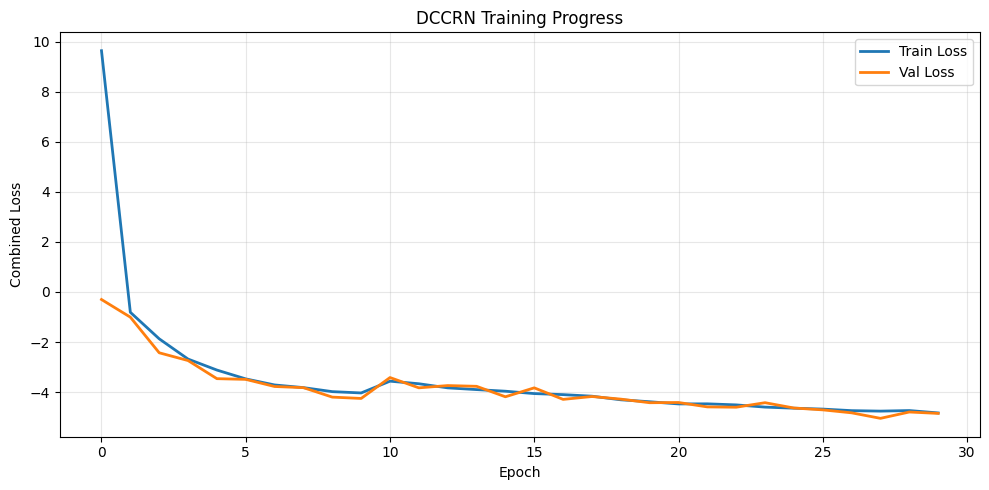

In [11]:
# CELL 9: Training curves visualization
# =========================================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(train_losses, label="Train Loss", linewidth=2)
ax.plot(val_losses, label="Val Loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined Loss")
ax.set_title("DCCRN Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

In [12]:
# CELL 10: Full Evaluation
# =========================================================================

def enhance_audio(model, noisy_waveform: np.ndarray) -> np.ndarray:
    """Enhance a single audio clip using the trained model."""
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(noisy_waveform.astype(np.float32)).unsqueeze(0).to(device)
        with autocast(enabled=cfg.USE_AMP):
            enhanced = model(x)
        return enhanced.squeeze(0).cpu().numpy()


print("Running comprehensive evaluation...")
print("=" * 80)

eval_records = []
audio_examples = {}

for snr_db in cfg.SNR_TEST_LEVELS:
    for i in range(cfg.NUM_TEST_PER_SNR):
        # Load fresh test pair
        sp_path = random.choice(speech_files)
        clean = load_audio(sp_path)
        clean = pad_or_crop(clean, cfg.CLIP_SAMPLES, random_crop=False)

        # Pick noise from random category
        cat = random.choice(list(noise_by_category.keys()))
        ns_path = random.choice(noise_by_category[cat])
        noise = load_audio(ns_path)

        mixture, clean = mix_at_snr(clean, noise, snr_db)

        # Enhance
        enhanced = enhance_audio(model, mixture)
        min_len = min(len(clean), len(enhanced))
        clean_eval = clean[:min_len]
        enhanced_eval = enhanced[:min_len]
        mixture_eval = mixture[:min_len]

        # Compute metrics
        snr_out = compute_snr(clean_eval, enhanced_eval)
        snr_in = compute_snr(clean_eval, mixture_eval)
        sisnr_out = compute_si_snr(clean_eval, enhanced_eval)
        pesq_val = compute_pesq_score(clean_eval, enhanced_eval)
        stoi_val = compute_stoi_score(clean_eval, enhanced_eval)

        eval_records.append({
            "input_snr_db": snr_db,
            "noise_type": cat,
            "snr_input": snr_in,
            "snr_output": snr_out,
            "delta_snr": snr_out - snr_in,
            "si_snr": sisnr_out,
            "pesq": pesq_val,
            "stoi": stoi_val,
        })

        # Save one example per SNR level for audio playback
        if snr_db not in audio_examples:
            audio_examples[snr_db] = {
                "clean": clean_eval, "noisy": mixture_eval,
                "enhanced": enhanced_eval, "noise_type": cat,
            }

    print(f"Evaluated SNR = {snr_db:+3d} dB: "
          f"{cfg.NUM_TEST_PER_SNR} pairs done")

# Create results DataFrame
eval_df = pd.DataFrame(eval_records)
eval_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "evaluation_full.csv"), index=False)

# Summary table
summary = eval_df.groupby("input_snr_db").agg({
    "snr_output": "mean",
    "delta_snr": "mean",
    "si_snr": "mean",
    "pesq": "mean",
    "stoi": "mean",
}).round(3)
summary.columns = ["Output SNR", "ΔSNR", "SI-SNR", "PESQ", "STOI"]
summary.to_csv(os.path.join(cfg.OUTPUT_DIR, "evaluation_summary.csv"))

print("\n" + "=" * 80)
print("DCCRN EVALUATION RESULTS")
print("Targets: SNR > 15 dB | PESQ > 2.5 | STOI > 0.85")
print("=" * 80)
print(summary.to_string())

# Per noise-type breakdown
print("\n\nPer Noise Type Breakdown:")
noise_summary = eval_df.groupby("noise_type").agg({
    "delta_snr": "mean", "pesq": "mean", "stoi": "mean",
}).round(3)
print(noise_summary.to_string())

Running comprehensive evaluation...


/tmp/ipykernel_22/1206552823.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.USE_AMP):


Evaluated SNR = -10 dB: 30 pairs done
Evaluated SNR =  -5 dB: 30 pairs done
Evaluated SNR =  +0 dB: 30 pairs done
Evaluated SNR =  +5 dB: 30 pairs done
Evaluated SNR = +10 dB: 30 pairs done
Evaluated SNR = +15 dB: 30 pairs done

DCCRN EVALUATION RESULTS
Targets: SNR > 15 dB | PESQ > 2.5 | STOI > 0.85
              Output SNR    ΔSNR  SI-SNR   PESQ   STOI
input_snr_db                                          
-10                1.449  11.449  -2.307  1.095  0.572
-5                 4.320   9.320   2.383  1.158  0.653
 0                 7.429   7.429   6.779  1.280  0.787
 5                10.220   5.220   9.954  1.422  0.858
 10               12.842   2.842  12.532  1.638  0.900
 15               15.403   0.403  15.578  1.908  0.938


Per Noise Type Breakdown:
             delta_snr   pesq   stoi
noise_type                          
unknown_010  12.836000  1.369  0.853
unknown_013   2.387000  1.773  0.950
unknown_018   3.027000  1.625  0.873
unknown_022   6.410000  1.073  0.464
unknown_

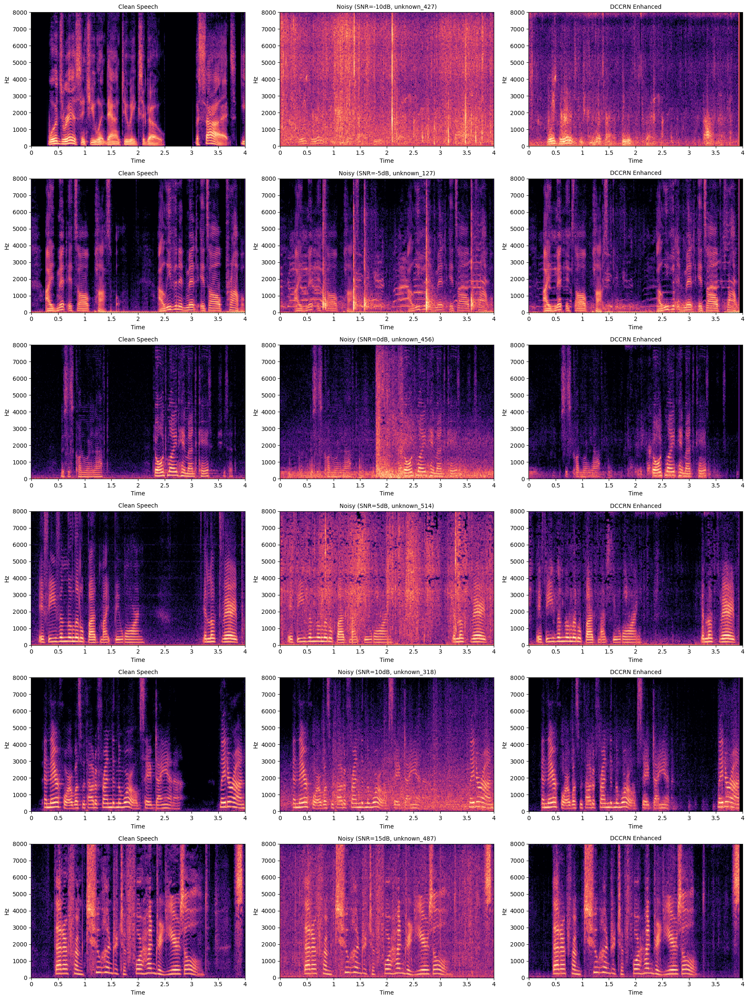


--- SNR = -10 dB (unknown_427) ---
Clean:


Noisy:


Enhanced:



--- SNR = -5 dB (unknown_127) ---
Clean:


Noisy:


...

Noisy:


Enhanced:



--- SNR = 15 dB (unknown_487) ---
Clean:


Noisy:


Enhanced:


In [13]:
# CELL 11: Audio examples & spectrograms
# =========================================================================

fig, axes = plt.subplots(len(audio_examples), 3, figsize=(18, 4 * len(audio_examples)))

for row, (snr_db, ex) in enumerate(sorted(audio_examples.items())):
    for col, (key, title) in enumerate([
        ("clean", "Clean Speech"),
        ("noisy", f"Noisy (SNR={snr_db}dB, {ex['noise_type']})"),
        ("enhanced", "DCCRN Enhanced"),
    ]):
        ax = axes[row, col] if len(audio_examples) > 1 else axes[col]
        D = librosa.amplitude_to_db(
            np.abs(librosa.stft(ex[key], n_fft=cfg.N_FFT, hop_length=cfg.HOP_LENGTH)),
            ref=np.max
        )
        librosa.display.specshow(D, sr=cfg.SR, hop_length=cfg.HOP_LENGTH,
                                  x_axis='time', y_axis='hz', ax=ax)
        ax.set_title(title, fontsize=10)
        ax.set_ylim(0, 8000)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, "spectrograms_comparison.png"), dpi=150)
plt.show()

# Audio playback
for snr_db, ex in sorted(audio_examples.items()):
    print(f"\n--- SNR = {snr_db} dB ({ex['noise_type']}) ---")
    print("Clean:")
    display(Audio(ex["clean"], rate=cfg.SR))
    print("Noisy:")
    display(Audio(ex["noisy"], rate=cfg.SR))
    print("Enhanced:")
    display(Audio(ex["enhanced"], rate=cfg.SR))

In [14]:
!pip install -q onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 754.2/754.2 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 11.7 MB/s eta 0:00:00


In [15]:
!pip install -q onnx onnxruntime onnxscript

In [16]:
import os, glob

print("Is 'model' still in memory?", 'model' in globals())

print("\nFiles in /kaggle/working:")
for f in glob.glob("/kaggle/working/**", recursive=True):
    print(" ", f)

Is 'model' still in memory? True

Files in /kaggle/working:
  /kaggle/working/
  /kaggle/working/checkpoints
  /kaggle/working/checkpoints/dccrn_epoch15.pt
  /kaggle/working/checkpoints/dccrn_epoch25.pt
  /kaggle/working/checkpoints/dccrn_epoch5.pt
  /kaggle/working/checkpoints/dccrn_epoch20.pt
  /kaggle/working/checkpoints/best_dccrn.pt
  /kaggle/working/checkpoints/dccrn_epoch10.pt
  /kaggle/working/checkpoints/dccrn_epoch30.pt
  /kaggle/working/evaluation_full.csv
  /kaggle/working/training_curves.png
  /kaggle/working/evaluation_summary.csv
  /kaggle/working/__notebook__.ipynb
  /kaggle/working/spectrograms_comparison.png


In [17]:
import os, glob, random
import numpy as np
import soundfile as sf
import librosa
import torch
import pandas as pd
from scipy.signal import fftconvolve
from pesq import pesq
from pystoi import stoi

# --- Ensure device & constants ---
SR = 16000
CLIP_SAMPLES = 64000  # 4 seconds
device = next(model.parameters()).device if 'model' in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Locate dataset files ---
print("Locating audio files...")
speech_files = sorted(glob.glob("/kaggle/input/**/*.flac", recursive=True))
noise_files = sorted(glob.glob("/kaggle/input/**/MAD_dataset/**/*.wav", recursive=True))

if len(noise_files) == 0:
    noise_files = sorted(glob.glob("/kaggle/input/**/*.wav", recursive=True))

print(f"Found {len(speech_files)} speech files and {len(noise_files)} noise files.")

# --- Helper functions ---
def load_audio(path, sr=SR):
    y, _ = librosa.load(path, sr=sr)
    return y

def pad_or_crop(audio, target_len=CLIP_SAMPLES, random_crop=False):
    if len(audio) < target_len:
        reps = int(np.ceil(target_len / max(len(audio), 1)))
        audio = np.tile(audio, reps)
    if len(audio) > target_len:
        start = random.randint(0, len(audio) - target_len) if random_crop else 0
        audio = audio[start:start + target_len]
    return audio[:target_len]

def compute_snr(clean, enhanced):
    min_len = min(len(clean), len(enhanced))
    c, e = clean[:min_len], enhanced[:min_len]
    noise = c - e
    return float(10 * np.log10(np.sum(c ** 2) / (np.sum(noise ** 2) + 1e-12)))

def compute_pesq_score(clean, enhanced, sr=SR):
    min_len = min(len(clean), len(enhanced))
    try:
        return float(pesq(sr, clean[:min_len], enhanced[:min_len], 'wb'))
    except Exception:
        return 1.0

def compute_stoi_score(clean, enhanced, sr=SR):
    min_len = min(len(clean), len(enhanced))
    return float(stoi(clean[:min_len], enhanced[:min_len], sr, extended=False))

# --- Dual-Microphone Simulation ---
def simulate_dual_mic(clean_speech, noise, snr_db=0.0, speech_leak_db=-20.0, transfer_filter_len=64):
    min_len = min(len(clean_speech), len(noise))
    clean_speech, noise = clean_speech[:min_len], noise[:min_len]

    np.random.seed(None)
    h = np.random.randn(transfer_filter_len) * 0.1
    h[0] = 1.0
    decay = np.exp(-np.arange(transfer_filter_len) / (transfer_filter_len / 3))
    h = (h * decay) / np.sqrt(np.sum((h * decay) ** 2))

    noise_at_primary = fftconvolve(noise, h, mode='same')
    clean_pwr = np.mean(clean_speech ** 2) + 1e-12
    noise_pwr = np.mean(noise_at_primary ** 2) + 1e-12
    scale = np.sqrt((clean_pwr / (10 ** (snr_db / 10))) / noise_pwr)
    noise_at_primary *= scale

    primary = clean_speech + noise_at_primary
    reference = noise * scale + clean_speech * (10 ** (speech_leak_db / 20))

    peak = max(np.max(np.abs(primary)), np.max(np.abs(reference)), 1e-6)
    if peak > 0.95:
        primary = primary * 0.95 / peak
        reference = reference * 0.95 / peak
        clean_speech = clean_speech * 0.95 / peak

    return {"primary": primary, "reference": reference, "clean": clean_speech}

# --- NLMS Adaptive Filter ---
class NLMSFilter:
    def __init__(self, filter_length=256, step_size=0.1, eps=1e-8):
        self.L, self.mu, self.eps = filter_length, step_size, eps
        self.w = np.zeros(filter_length)

    def process(self, primary, reference):
        n = min(len(primary), len(reference))
        out = np.zeros(n)
        ref_pad = np.concatenate([np.zeros(self.L - 1), reference[:n]])
        for i in range(n):
            x = ref_pad[i:i + self.L][::-1]
            e = primary[i] - np.dot(self.w, x)
            out[i] = e
            self.w += self.mu * e * x / (np.dot(x, x) + self.eps)
        return out

# --- Run Hybrid Evaluation ---
print("Running comparative evaluation (Noisy -> DCCRN -> Hybrid)...")
records = []
test_snrs = [-10, -5, 0, 5, 10, 15]

model.eval()

for snr_db in test_snrs:
    for i in range(15):  # 15 test pairs per SNR
        sp_path = random.choice(speech_files)
        clean = pad_or_crop(load_audio(sp_path), CLIP_SAMPLES, random_crop=False)
        ns_path = random.choice(noise_files)
        noise = pad_or_crop(load_audio(ns_path), CLIP_SAMPLES)

        dual = simulate_dual_mic(clean, noise, snr_db=snr_db)

        # Stage 1: DCCRN Neural Enhancement
        with torch.no_grad():
            x_in = torch.from_numpy(dual["primary"].astype(np.float32)).unsqueeze(0).to(device)
            dccrn_out = model(x_in).squeeze(0).cpu().numpy()

        # Stage 2: NLMS Adaptive Post-Filter
        nlms = NLMSFilter(filter_length=256, step_size=0.1)
        hybrid_out = nlms.process(dccrn_out, dual["reference"])

        min_l = min(len(dual["clean"]), len(hybrid_out))
        c_eval = dual["clean"][:min_l]
        p_eval = dual["primary"][:min_l]
        n_eval = dccrn_out[:min_l]
        h_eval = hybrid_out[:min_l]

        records.append({
            "SNR_In": snr_db,
            "Noisy_SNR": compute_snr(c_eval, p_eval),
            "DCCRN_SNR": compute_snr(c_eval, n_eval),
            "Hybrid_SNR": compute_snr(c_eval, h_eval),
            "Noisy_STOI": compute_stoi_score(c_eval, p_eval),
            "DCCRN_STOI": compute_stoi_score(c_eval, n_eval),
            "Hybrid_STOI": compute_stoi_score(c_eval, h_eval),
            "Noisy_PESQ": compute_pesq_score(c_eval, p_eval),
            "DCCRN_PESQ": compute_pesq_score(c_eval, n_eval),
            "Hybrid_PESQ": compute_pesq_score(c_eval, h_eval),
        })
    print(f"  SNR {snr_db:+3d} dB: done")

df_hybrid = pd.DataFrame(records)
summary = df_hybrid.groupby("SNR_In").mean().round(3)

print("\n" + "=" * 95)
print("FINAL COMPARISON: Noisy vs DCCRN vs DCCRN+NLMS Hybrid")
print("=" * 95)
print(summary.to_string())

summary.to_csv("/kaggle/working/hybrid_comparison_summary.csv")
print("\n✓ Saved to /kaggle/working/hybrid_comparison_summary.csv")

Locating audio files...
Found 137876 speech files and 7466 noise files.
Running comparative evaluation (Noisy -> DCCRN -> Hybrid)...
  SNR -10 dB: done
  SNR  -5 dB: done
  SNR  +0 dB: done
  SNR  +5 dB: done
  SNR +10 dB: done
  SNR +15 dB: done

FINAL COMPARISON: Noisy vs DCCRN vs DCCRN+NLMS Hybrid
        Noisy_SNR  DCCRN_SNR  Hybrid_SNR  Noisy_STOI  DCCRN_STOI  Hybrid_STOI  Noisy_PESQ  DCCRN_PESQ  Hybrid_PESQ
SNR_In                                                                                                            
-10         -10.0      3.235      -0.373       0.495       0.605        0.539       1.066       1.097        1.067
-5           -5.0      4.975      -0.845       0.594       0.692        0.552       1.114       1.205        1.087
 0           -0.0      7.801       0.708       0.708       0.795        0.617       1.124       1.279        1.080
 5            5.0      9.847       0.839       0.824       0.870        0.676       1.210       1.419        1.072
 10     

In [18]:
from IPython.display import FileLink

# Zip all your results into one clean package
!zip -q -j /kaggle/working/sih_results.zip /kaggle/working/dccrn_weights.pt /kaggle/working/*.csv

print("Click the link below to download everything:")
FileLink("sih_results.zip")

Click the link below to download everything:


/kaggle/working/sih_results.zip

In [19]:
torch.save(model.state_dict(), "/kaggle/working/dccrn_weights.pt")